In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

F:\DeepLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\me03h\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1


C:\Users\me03h\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import os

import torch
import torchvision
import torchvision.transforms as transforms

['asl_alphabet_test', 'asl_alphabet_train']
C:\Users\me03h\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train\asl_alphabet_train\A\A1.jpg


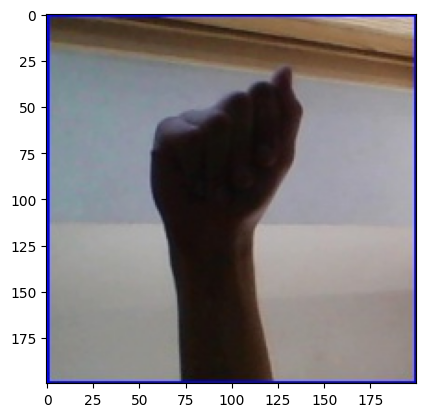

In [4]:
classes = os.listdir(path)
print(classes)


train_path = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')
test_path = os.path.join(path, 'asl_alphabet_test', 'asl_alphabet_test')

img_path = os.path.join(train_path, 'A', 'A1.jpg')
print(img_path)

img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

In [5]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.ImageFolder(root=train_path, transform=transform)
print(trainset)
batch_size = 8
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

classes = ('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space')

testset = torchvision.datasets.ImageFolder(root=test_path, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
print(testset)


Dataset ImageFolder
    Number of datapoints: 87000
    Root location: C:\Users\me03h\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train\asl_alphabet_train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )
Dataset ImageFolder
    Number of datapoints: 29
    Root location: C:\Users\me03h\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_test\asl_alphabet_test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


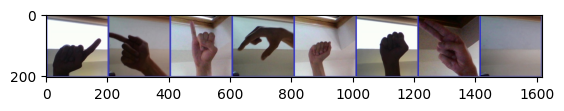

Z     G     I     Q     A     S     H     nothing


In [7]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features=128 * 25 * 25, out_features=512)
        self.fc2 = nn.Linear(in_features=512, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=29)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # no relu as using softmax in the end
        return x

CNN = CNN()
CNN.to(device)
print(CNN)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=80000, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=29, bias=True)
)


In [9]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(CNN.parameters(), lr=0.001, momentum=0.9)

for epoch in range(2):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = CNN(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'Epoch: {epoch + 1}, [{i + 1}, {len(trainloader)}] loss: {loss.item():.3f}  '
                  f'Running loss: {running_loss / 100:.3f}')
            running_loss = 0.0


Epoch: 1, [100, 10875] loss: 3.364  Running loss: 3.367
Epoch: 1, [200, 10875] loss: 3.340  Running loss: 3.365
Epoch: 1, [300, 10875] loss: 3.338  Running loss: 3.365
Epoch: 1, [400, 10875] loss: 3.364  Running loss: 3.362
Epoch: 1, [500, 10875] loss: 3.353  Running loss: 3.353
Epoch: 1, [600, 10875] loss: 3.315  Running loss: 3.342
Epoch: 1, [700, 10875] loss: 3.336  Running loss: 3.306
Epoch: 1, [800, 10875] loss: 3.150  Running loss: 3.184
Epoch: 1, [900, 10875] loss: 2.906  Running loss: 3.010
Epoch: 1, [1000, 10875] loss: 3.170  Running loss: 2.951
Epoch: 1, [1100, 10875] loss: 2.625  Running loss: 2.754
Epoch: 1, [1200, 10875] loss: 2.371  Running loss: 2.579
Epoch: 1, [1300, 10875] loss: 2.517  Running loss: 2.529
Epoch: 1, [1400, 10875] loss: 3.037  Running loss: 2.461
Epoch: 1, [1500, 10875] loss: 1.998  Running loss: 2.321
Epoch: 1, [1600, 10875] loss: 1.693  Running loss: 2.276
Epoch: 1, [1700, 10875] loss: 2.172  Running loss: 2.331
Epoch: 1, [1800, 10875] loss: 1.207  Run

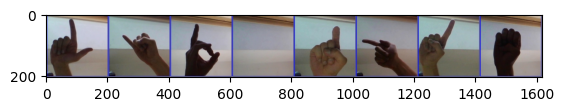

GroundTruth:  L     J     D     nothing X     G     Z     E    


In [10]:
dataiter = iter(testloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [11]:
images, labels = images.to(device), labels.to(device)
outputs = CNN(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(batch_size)))

Predicted:  L     J     D     nothing V     G     Z     E    


In [12]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = CNN(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the {total} test images: {100 * correct // total} %')

Accuracy of the network on the 29 test images: 93 %
